# Trabajo Práctico AA1 - Clasificación

In [912]:
# manipulación, visualización y modelado.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# separación de datos, modelos y métricas.
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc

# preprocesamiento.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# geolocalización y visualización de ubicaciones.
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from folium import Map, Marker, Icon
from sklearn.cluster import KMeans

## Carga dataset

In [913]:
# Cargamos el dataset
df_original = pd.read_csv("content/weatherAUS_2026C1.csv")
#df_original = pd.read_csv("./content/weatherAUS_2026C1.csv")
df_original.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [914]:
#copiamos el dataset para mantener el original
df = df_original.copy()

In [915]:
# revisamos las columnas
df.columns

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='str')

In [916]:
# cantidad de filas y columnas
df.shape

(145412, 25)

In [917]:
# revisamos tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

### Descripción de variables

- Date: fecha de la observación.
- Location: ciudad o estación meteorológica donde se tomó la observación.
- MinTemp: temperatura mínima registrada durante el día.
- MaxTemp: temperatura máxima registrada durante el día.
- Rainfall: cantidad de lluvia registrada durante el día.
- Evaporation: evaporación registrada.
- Sunshine: cantidad de horas de sol.
- WindGustDir: dirección de la ráfaga de viento más fuerte.
- WindGustSpeed: velocidad de la ráfaga de viento más fuerte.
- WindDir9am: dirección del viento a las 9am.
- WindDir3pm: dirección del viento a las 3pm.
- WindSpeed9am: velocidad del viento a las 9am.
- WindSpeed3pm: velocidad del viento a las 3pm.
- Humidity9am: humedad a las 9am.
- Humidity3pm: humedad a las 3pm.
- Pressure9am: presión atmosférica a las 9am.
- Pressure3pm: presión atmosférica a las 3pm.
- Cloud9am: nubosidad a las 9am.
- Cloud3pm: nubosidad a las 3pm.
- Temp9am: temperatura a las 9am.
- Temp3pm: temperatura a las 3pm.
- RainToday: indica si llovió durante el día actual.
- RainTomorrow: variable objetivo; indica si llovió al día siguiente.
- RainfallTomorrow: Cantidad de lluvia al día siguiente

In [918]:
df.isnull().sum()

Unnamed: 0              0
Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64

Se detectan valores faltantes en varias columnas, por lo que será necesario tratarlo según el caso.

In [919]:
df = df.drop(columns=["Unnamed: 0"])

La columna "Unnamed: 0" parece ser un índice guardado en el archivo CSV, por lo que no representa una variable climática útil para la predicción. Por este motivo se elimina del análisis.

In [920]:
df = df.drop(columns=["RainfallTomorrow"])

In [921]:
# verificamos que hayan sido eliminadas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')

La columna "RainfallTomorrow" no se utiliza como variable predictora porque contiene información asociada al día siguiente. Como el objetivo es predecir a las 23:59 hs si al día siguiente lloverá o no, esta información no estaría disponible al momento de realizar la predicción. Usarla produciría fuga de datos.

## EDA

### Locations

In [922]:
def CamelCase(cadena: str) -> str:
  """
  Funcion para modificar el nombre de las variables porque sino tira error por como esta hecha.
  """
  resultado = ""
  for i, caracter in enumerate(cadena):
    if i > 0 and caracter.isupper() and cadena[i-1].islower():
      resultado += " "
    resultado += caracter
  return resultado

In [923]:
ciudades = df['Location'].unique()
geolocator = Nominatim(user_agent="climate_region_clustering")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)  # evita baneos por rate limit
# Obtener coordenadas
coords = []
contador = 0
for ciudad in ciudades:
  location = geocode(f"{CamelCase(ciudad)}, Australia")
  if location:
    lat = location.latitude
    lon = location.longitude
    coords.append((ciudad, lat, lon))
    contador += 1
  else:
    print(f"No se encontró: {ciudad}")
    coords.append((ciudad, None, None))

df_coords = pd.DataFrame(coords, columns=["Location", "Latitude", "Longitude"])
print(f"Se cargaron correctamente {contador} ciudades.")

Se cargaron correctamente 49 ciudades.


In [924]:
map = Map(location=[-25.0, 133.0], zoom_start=4)
for _, row in df_coords.iterrows():
  Marker(location=[row['Latitude'], row['Longitude']], popup=row['Location'], icon=Icon()).add_to(map)
map

Ahora que tenemos las coordenadas y las ciudades ubicadas, las agrupamos en Regiones

In [925]:
# Aplicar KMeans sobre latitud y longitud
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
df_coords["Region"] = kmeans.fit_predict(df_coords[["Latitude", "Longitude"]])

In [926]:
colores = ['red', 'pink', 'green', 'purple', 'orange', 'darkred', 'darkgreen', 'darkblue', 'black', 'blue']

map = Map(location=[-25.0, 133.0], zoom_start=4)
for _, row in df_coords.iterrows():
  # Elegir el color según el cluster
  color = colores[row['Region'] % len(colores)]
  Marker(location=[row['Latitude'], row['Longitude']], popup=f"{row['Location']} (Cluster {row['Region']})", icon=Icon(color=color)).add_to(map)
map

In [927]:
# Agregar Region al df original
df = df.merge(df_coords[['Location', 'Region']], on='Location', how='left')

In [928]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Region
0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,9
1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,9
2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,9
3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,9
4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,ENE,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145407,2017-06-20,Uluru,2.6,22.0,0.0,NaN,NaN,E,29.0,ESE,...,26.5,1024.8,1021.2,NaN,NaN,10.1,21.6,No,No,8
145408,2017-06-21,Uluru,3.1,23.2,0.0,NaN,NaN,E,31.0,SE,...,24.7,1024.3,1020.5,NaN,NaN,11.1,21.5,No,No,8
145409,2017-06-22,Uluru,3.6,26.0,0.0,NaN,NaN,NNW,21.0,SE,...,21.4,1023.3,1018.4,NaN,NaN,11.8,24.5,No,No,8
145410,2017-06-23,Uluru,4.8,27.4,0.0,NaN,NaN,N,39.0,SE,...,23.7,1021.0,1016.0,NaN,NaN,12.0,26.9,No,No,8


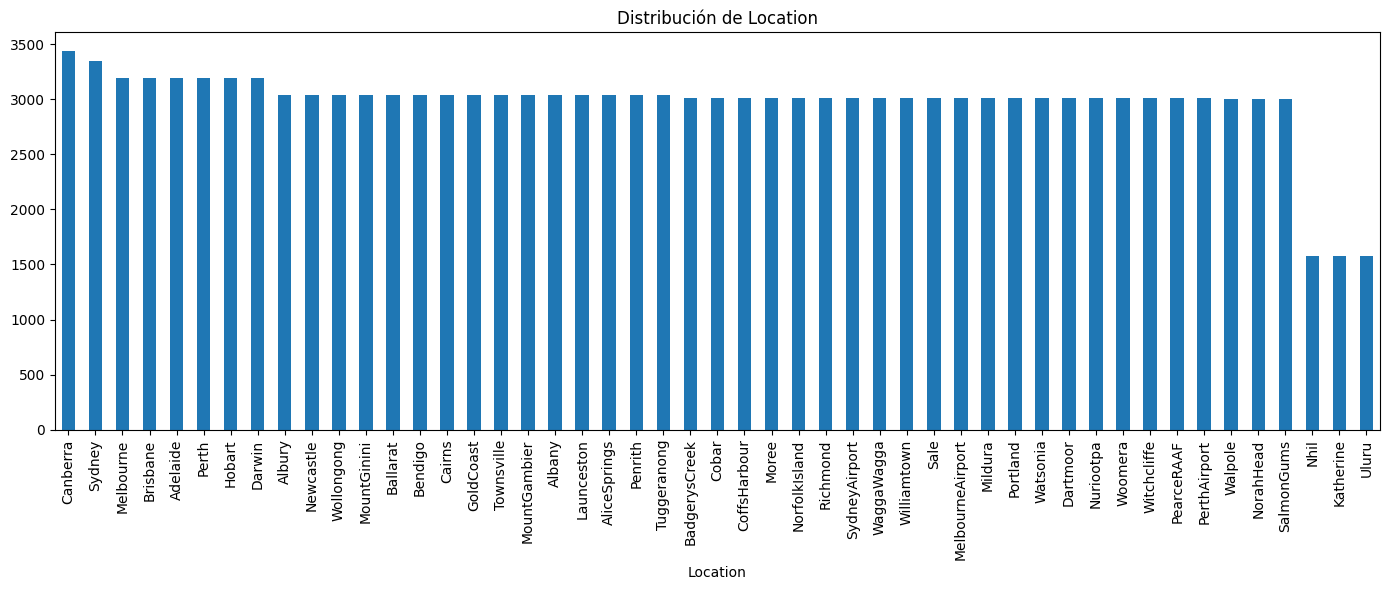

In [929]:
df['Location'].value_counts().plot(kind='bar', figsize=(14, 6))
plt.title("Distribución de Location")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [930]:
df = df.drop(columns=['Location'])

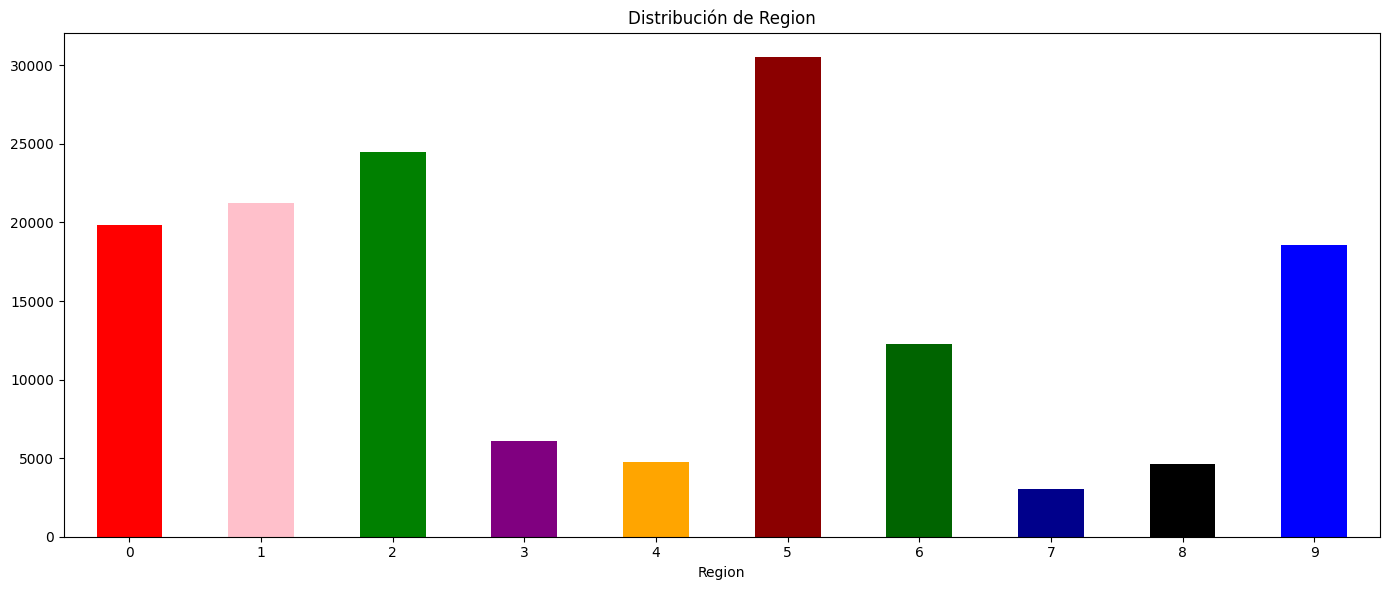

In [931]:
df['Region'].value_counts().sort_index().plot(kind='bar', figsize=(14, 6), color=colores)
plt.title("Distribución de Region")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###

In [932]:
# revisamos los valores de la variable objetivo
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
NaN      3259
Name: count, dtype: int64

In [933]:
# Calculamos la proporción de cada clase
df["RainTomorrow"].value_counts(normalize=True, dropna=False)

RainTomorrow
No     0.758404
Yes    0.219184
NaN    0.022412
Name: proportion, dtype: float64

In [934]:
# eliminamos filas donde la variable objetivo no tiene valor
df = df.dropna(subset=["RainTomorrow"])
# verificamos
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

In [935]:
df_nuevo = df.copy()

In [936]:
# separamos variables predictoras y variable objetivo.
X = df_nuevo.drop(columns=["RainTomorrow"])
y = df_nuevo["RainTomorrow"]
#y = y.map({"No": 0, "Yes": 1})

In [937]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [938]:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [939]:
type(y)

pandas.Series

In [940]:
type(y_train)

pandas.Series

In [941]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

113722
28431
113722
28431


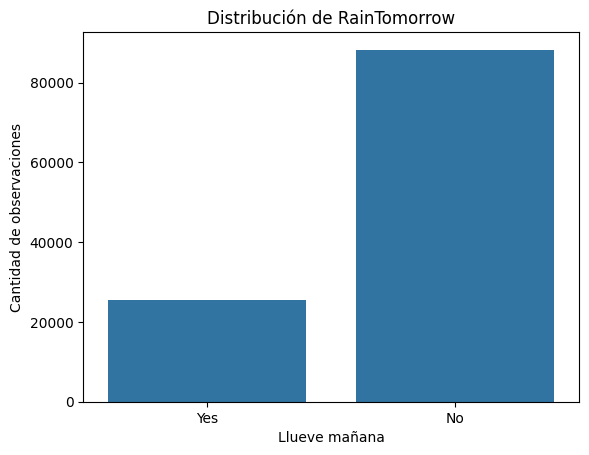

In [942]:
# Graficamos la distribución de la variable objetivo
sns.countplot(data=df_train,x="RainTomorrow", order=["Yes", "No"])
plt.title("Distribución de RainTomorrow")
plt.xlabel("Llueve mañana")
plt.ylabel("Cantidad de observaciones")
plt.show()

La variable objetivo del problema es "RainTomorrow", que indica si al día siguiente llovió o no. En distribución observamos que la clase "No" aparece con mucha mayor frecuencia que la clase "Yes". Por ende el dataset está desbalanceado, por este motivo, además de accuracy, será necesario observar métricas como precision, recall y F1-score, especialmente para la clase "Yes". Sino el modelo puede no aprender a detectar bien los dias que si llueve


In [943]:
# eliminamos filas donde la variable objetivo no tiene valor
#df_train = df_train.dropna(subset=["RainTomorrow"])


In [944]:
# verificamos
#df_train["RainTomorrow"].value_counts(dropna=False)

Las filas con valores faltantes en "RainTomorrow" se eliminan porque esta columna es la variable objetivo. Si no se conoce si al día siguiente llovió o no, esa observación no puede utilizarse para entrenar ni evaluar un modelo supervisado.

In [945]:
df_train.dtypes

Date                 str
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir          str
WindGustSpeed    float64
WindDir9am           str
WindDir3pm           str
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday            str
Region             int32
RainTomorrow         str
dtype: object

In [946]:
# calculamos cantidad y porcentaje de valores faltantes por columna
faltantes = pd.DataFrame({
    "cantidad_faltantes": df_train.isna().sum(),
    "porcentaje_faltantes": df_train.isna().mean() * 100
})

faltantes = faltantes.sort_values(by="porcentaje_faltantes", ascending=False)

faltantes

,cantidad_faltantes,porcentaje_faltantes
Sunshine,54326,47.770880
Evaporation,48714,42.836039
Cloud3pm,45699,40.184837
Cloud9am,42889,37.713899
Pressure9am,11291,9.928598
Pressure3pm,11274,9.913649
WindDir9am,8058,7.085700
WindGustDir,7443,6.544908
WindGustSpeed,7394,6.501820
WindDir3pm,3073,2.702204


Observamos que algunas variables presentan un porcentaje alto de valores faltantes, por este motivo no se eliminan filas completas con valores faltantes, ya que eso implicaría perder una gran cantidad de observaciones. Se decide conservar inicialmente las variables y realizar la imputación más adelante después de separar los datos en entrenamiento y prueba.


In [947]:
# identificamos variables numéricas y categóricas
columnas_numericas = df_train.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = df_train.select_dtypes(include=["object","int32"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')

Variables categóricas:
Index(['Date', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday',
       'Region', 'RainTomorrow'],
      dtype='str')


C:\Users\valen\AppData\Local\Temp\ipykernel_5268\753316716.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df_train.select_dtypes(include=["object","int32"]).columns


In [948]:
# obtenemos medidas descriptivas de las variables numéricas
df_train[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,113210.0,12.174022,6.426738,-9.7,7.6,12.0,16.8,34.1
MaxTemp,113470.0,23.212820,7.131541,-5.1,17.9,22.6,28.2,49.1
Rainfall,112582.0,2.362902,8.588292,0.0,0.0,0.0,0.6,371.0
Evaporation,65008.0,5.466721,4.209742,0.0,2.6,4.8,7.4,145.0
Sunshine,59396.0,7.617550,3.785206,0.0,4.9,8.5,10.6,14.5
WindGustSpeed,106328.0,39.963547,13.628109,6.0,31.0,38.0,47.0,135.0
WindSpeed9am,112641.0,14.018057,8.908431,0.0,7.0,13.0,19.0,88.0
WindSpeed3pm,111587.0,18.631023,8.848357,0.0,12.0,18.0,24.0,82.0
Humidity9am,112295.0,68.854287,19.099642,0.0,56.9,70.0,83.1,100.0
Humidity3pm,110806.0,51.506860,20.841426,0.0,36.6,52.0,65.7,100.0


Calculamos las medidas para las variables numéricas para detectar diferencias de escala entre variables

In [949]:
# obtenemos un resumen de las variables categóricas.
df_train[columnas_categoricas].describe().T

,count,mean,std,min,25%,50%,75%,max
Region,113722.0,3.846151,2.942516,0.0,1.0,4.0,6.0,9.0


En este caso interesa observar cuántas categorías distintas tiene cada variable y cuál es el valor más frecuente

### Histogramas

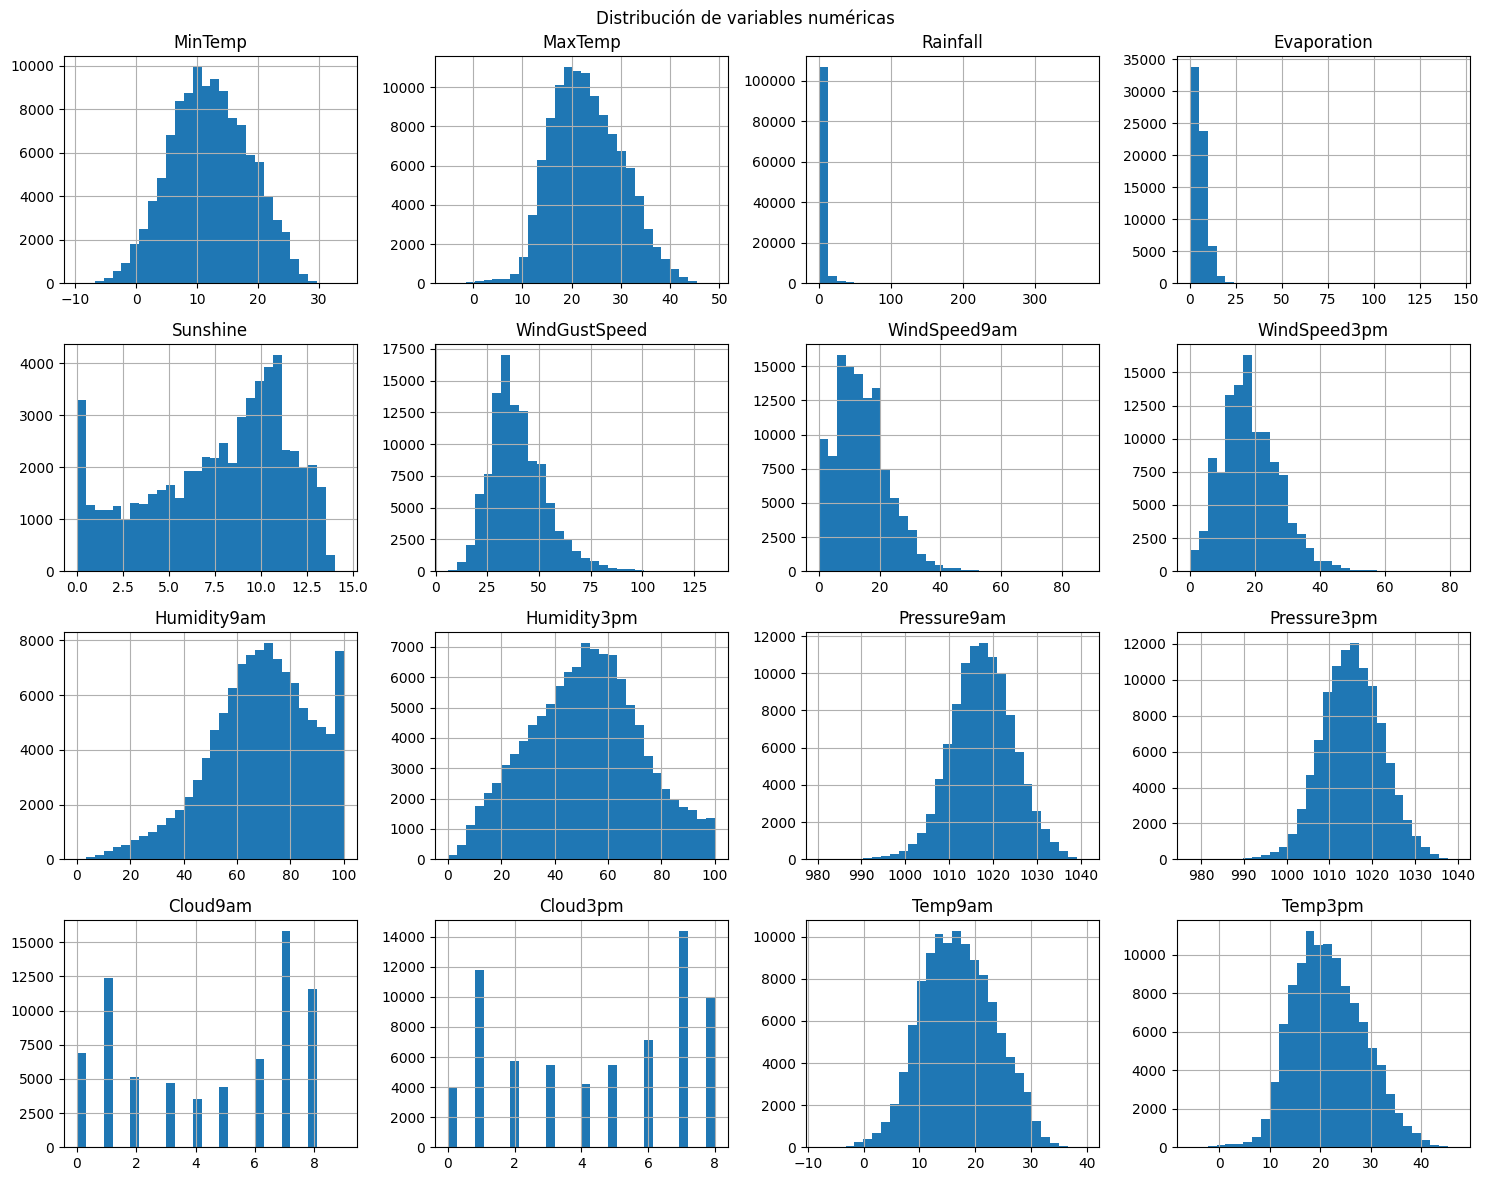

In [950]:
# graficamos histogramas para observar la distribución de las variables numéricas.
df_train[columnas_numericas].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

Graficamos histogramas de las variables numéricas para observar su distribución. Observamos que las variables no se encuentran en la misma escala, por ejemplo, temperatura, presión, humedad, velocidad del viento y lluvia tienen unidades y rangos distintos. Por este motivo, más adelante será necesario aplicar escalado

### Boxplots

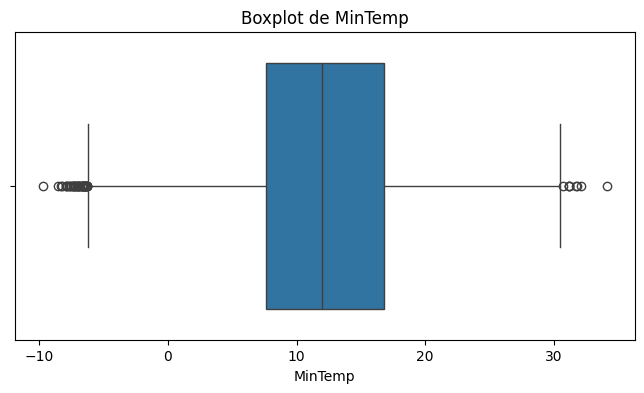

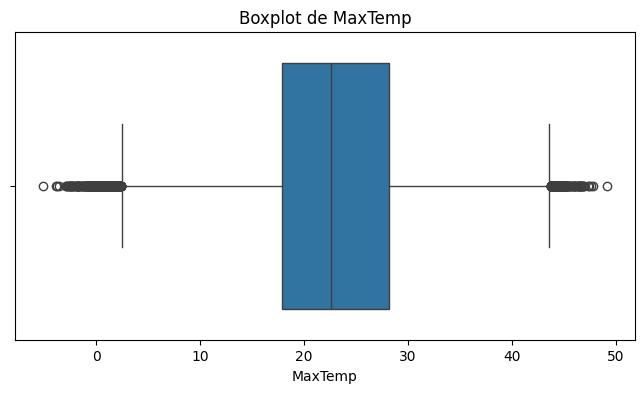

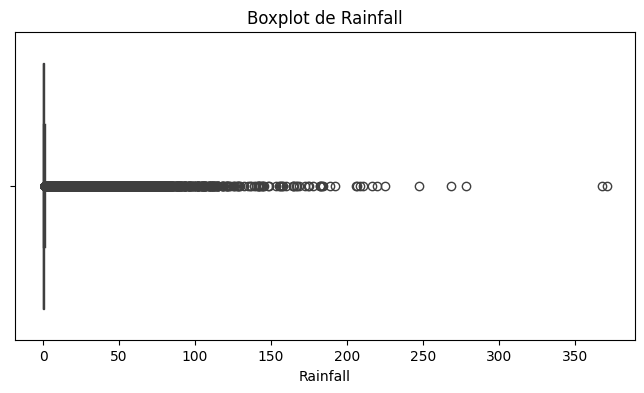

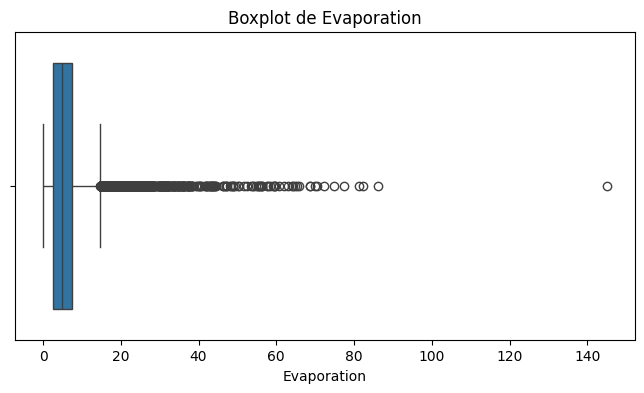

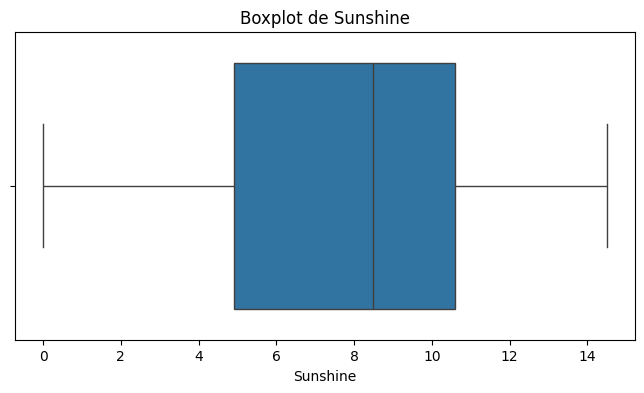

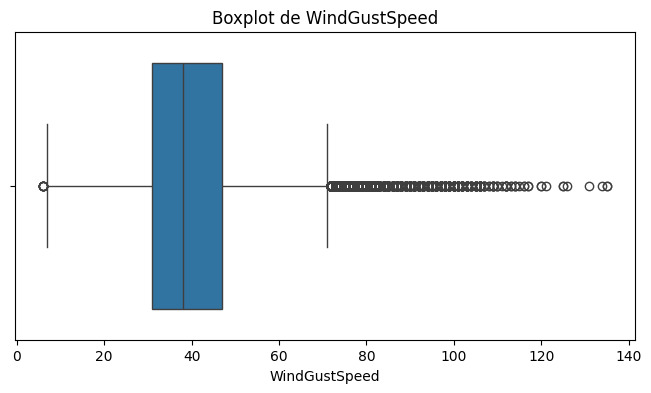

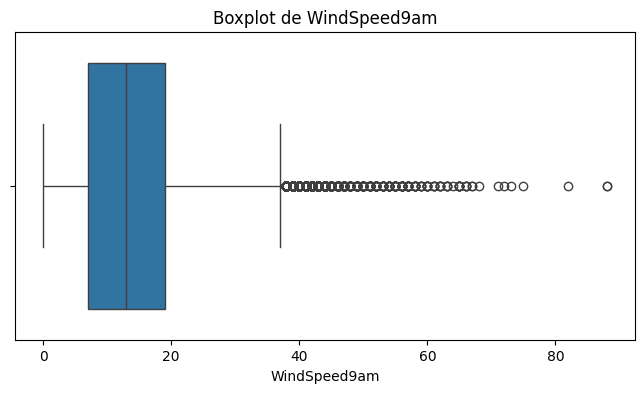

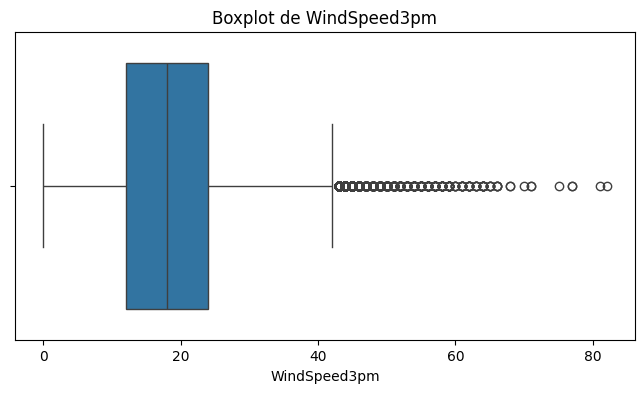

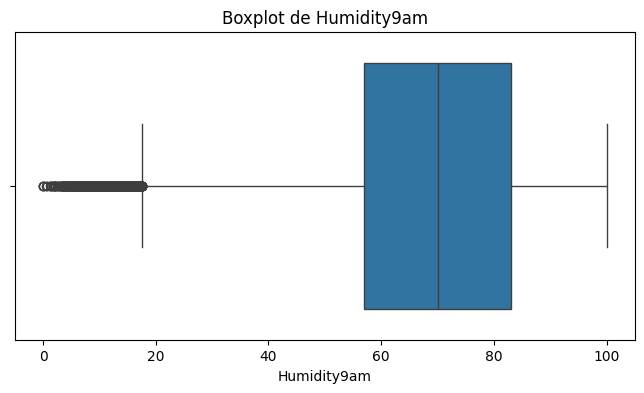

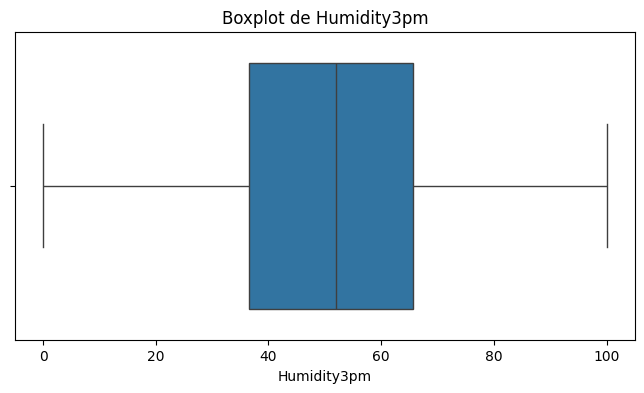

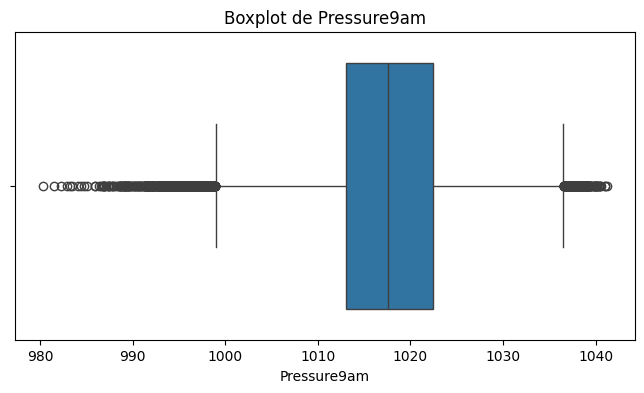

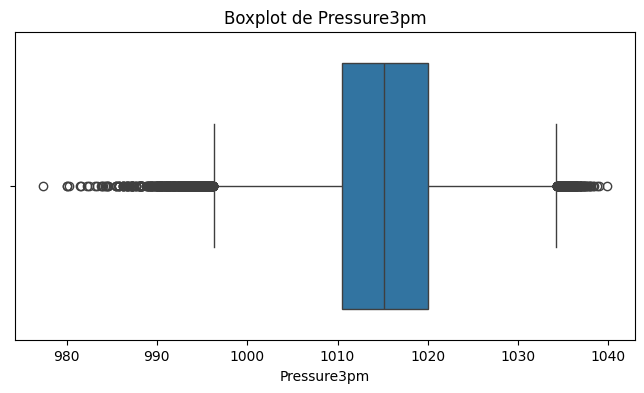

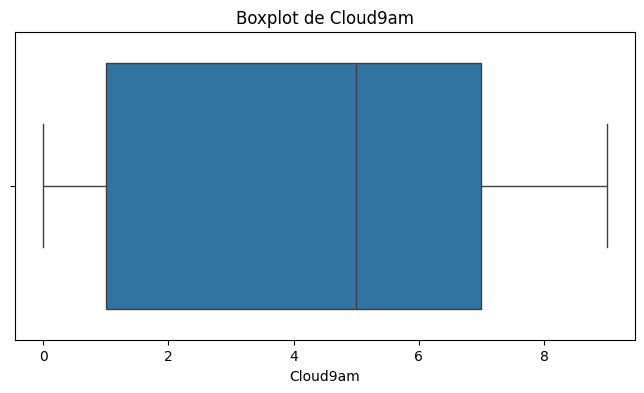

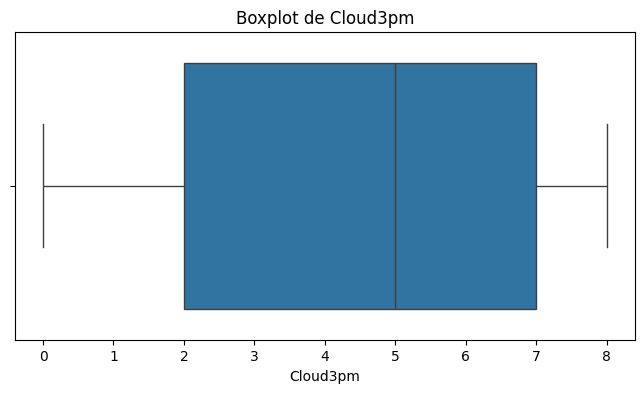

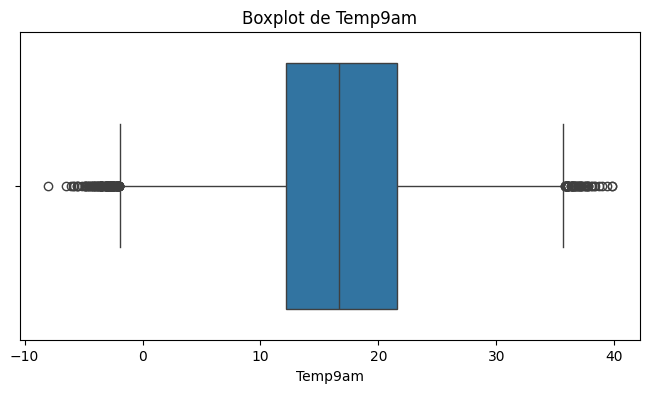

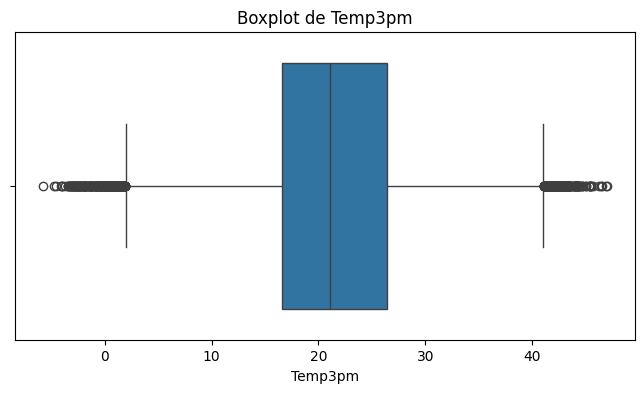

In [951]:
# Graficamos boxplots individuales para todas las variables numéricas.
for columna in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_train, x=columna)
    plt.title(f"Boxplot de {columna}")
    plt.xlabel(columna)
    plt.show()

In [952]:
# calculamos outliers por variable numérica usando el criterio del rango intercuartílico
resumen_outliers = []

for columna in columnas_numericas:
    q1 = df_train[columna].quantile(0.25)
    q3 = df_train[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    cantidad_outliers = ((df_train[columna] < limite_inferior) | (df_train[columna] > limite_superior)).sum()

    porcentaje_outliers = cantidad_outliers / df_train[columna].notna().sum() * 100

    resumen_outliers.append({
        "variable": columna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": cantidad_outliers,
        "porcentaje_outliers": porcentaje_outliers
    })

resumen_outliers = pd.DataFrame(resumen_outliers)
resumen_outliers.sort_values(by="porcentaje_outliers", ascending=False)

,variable,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
2,Rainfall,-0.90,1.50,22829,20.277664
5,WindGustSpeed,7.00,71.00,2874,2.702957
3,Evaporation,-4.60,14.60,1555,2.392013
6,WindSpeed9am,-11.00,37.00,1497,1.329001
7,WindSpeed3pm,-6.00,42.00,1308,1.172180
8,Humidity9am,17.60,122.40,1147,1.021417
10,Pressure9am,998.90,1036.50,1029,1.004579
11,Pressure3pm,996.25,1034.25,810,0.790645
15,Temp3pm,1.90,41.10,595,0.533556
1,MaxTemp,2.45,43.65,393,0.346347


In [953]:
# verificamos si existen valores negativos en variables que no deberían ser negativas
variables_no_negativas = ["Rainfall", "Evaporation", "Sunshine","WindGustSpeed", "WindSpeed9am", "WindSpeed3pm","Humidity9am", "Humidity3pm","Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm"]

valores_negativos = {}

for columna in variables_no_negativas:
    cantidad_negativos = (df_train[columna] < 0).sum()
    valores_negativos[columna] = cantidad_negativos

pd.Series(valores_negativos).sort_values(ascending=False)

Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
dtype: int64

In [954]:
# observamos los valores más frecuentes de Rainfall
df_train["Rainfall"].value_counts().head(20)

Rainfall
0.0    72226
0.2     6959
0.4     3000
0.6     2062
0.8     1616
1.0     1378
1.2     1181
1.4     1089
1.6      954
1.8      871
2.0      832
2.2      772
2.4      677
2.6      665
2.8      590
3.0      557
3.2      537
3.4      472
3.8      467
3.6      447
Name: count, dtype: int64

Analizamos posibles valores extremos utilizando el criterio del rango intercuartílico (IQR). Este criterio marca como posibles outliers los valores menores a Q1 - 1.5 * IQR o mayores a Q3 + 1.5 * IQR. Observamos también que una gran parte de las observaciones tiene lluvia igual o cercana a 0 mm. Esto hace que el rango intercuartílico sea bajo y que valores de lluvia mayores a 2 mm sean marcados como outliers. Estos valores no necesariamente representan errores, sino que pueden ser días con mayor cantidad de lluvia.

### Matriz de correlación

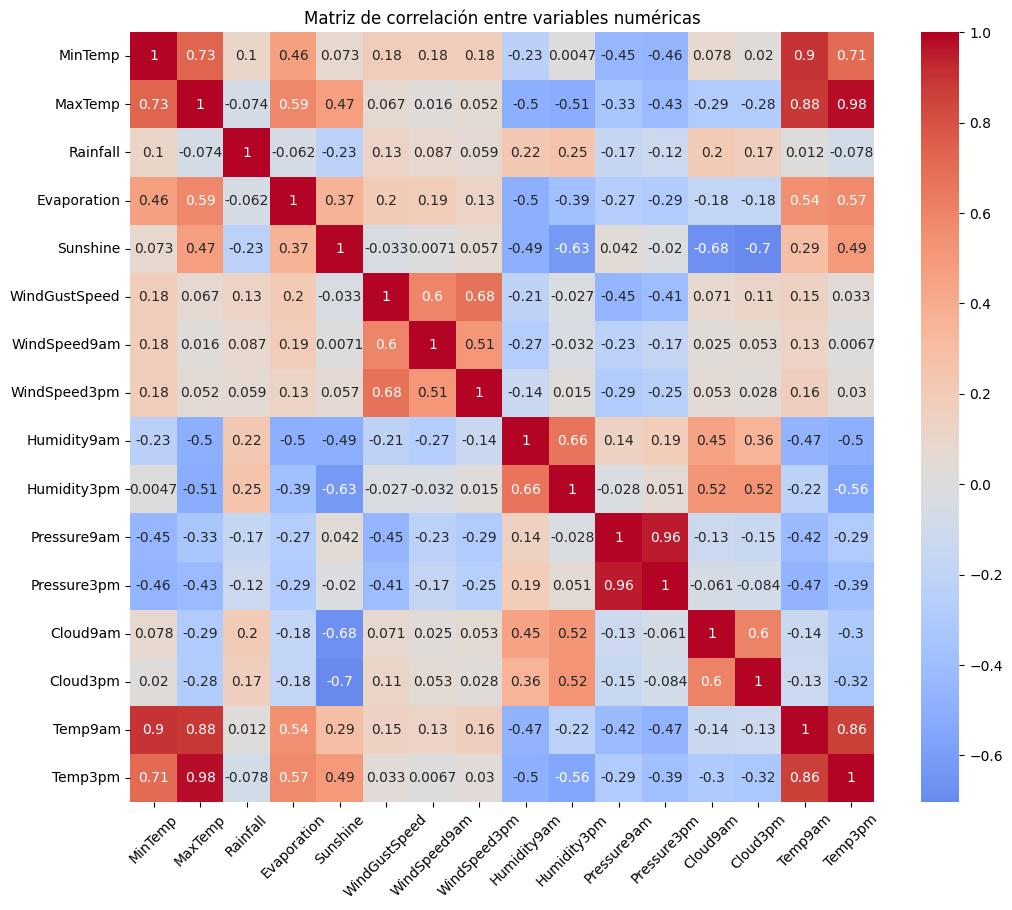

In [955]:
# calculamos la matriz de correlación entre variables numéricas
correlacion = df_train[columnas_numericas].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.xticks(rotation=45)
plt.show()

Se identifican correlaciones positivas fuertes entre variables relacionadas con la temperatura, como "MaxTemp" y "Temp3pm", y entre variables de presión, como "Pressure9am" y "Pressure3pm", también se observan correlaciones negativas entre "Sunshine" y variables como "Cloud9am", "Cloud3pm" y "Humidity3pm", lo cual es coherente con el clima, a mayor nubosidad o humedad o menor cantidad de horas de sol.
Esta matriz se utiliza como análisis exploratorio. No se eliminan variables automáticamente por correlación en esta etapa

In [956]:
df_train[columnas_categoricas].nunique()

Date            3409
WindGustDir       16
WindDir9am        16
WindDir3pm        16
RainToday          2
Region            10
RainTomorrow       2
dtype: int64

In [957]:
# convertimos Date a formato fecha y extraemos el mes como variable numérica
df_train["Date"] = pd.to_datetime(df_train["Date"])
df_train["Month"] = df_train["Date"].dt.month

df_train = df_train.drop(columns=["Date"])

df_test["Date"] = pd.to_datetime(df_test["Date"])
df_test["Month"] = df_test["Date"].dt.month
# eliminamos la columna Date original para evitar codificar fechas completas

df_test = df_test.drop(columns=["Date"])

## 

Cambiamos la variable mes por Season para bajar las opciones de la variable de 12 a 4 y bajar la dimensionalidad del modelo

In [958]:
def asignar_estacion(mes):
    if mes in [12, 1, 2]:
        return 'Summer'
    elif mes in [3, 4, 5]:
        return 'Autumn'
    elif mes in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

df_train['Season'] = df_train['Month'].apply(asignar_estacion)
# Eliminamos la variable original
df_train.drop('Month', axis=1, inplace = True)
df_test['Season'] = df_test['Month'].apply(asignar_estacion)
# Eliminamos la variable original
df_test.drop('Month', axis=1, inplace = True)

In [959]:
X_train = df_train.drop(columns=["RainTomorrow"])
X_test = df_test.drop(columns=["RainTomorrow"])

y_train = df_train["RainTomorrow"]
y_test = df_test["RainTomorrow"]

Vemos que Location tiene demasiadas categorias en comparacion con las demas porque son ciudades, podemos reducirla agrupando por regiones mas grandes en vez de por ciudad

La columna "Date" se convierte a formato fecha y se utiliza para extraer el mes de la observación, lo que perermite conservar información  sobre estaciones, ya que la probabilidad de lluvia puede variar según la época del año. Luego se elimina la fecha completa, porque codificar cada día como una categoría distinta generaría muchas columnas y no aportaría una representación simple para el modelo.

In [960]:
#X = df_modelo.drop(columns=["RainTomorrow"])
#y = df_modelo["RainTomorrow"]

In [961]:
#y = y.map({"No": 0, "Yes": 1})

In [962]:
# codificamos la variable objetivo: No = 0, Yes = 1.
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [963]:
y = pd.concat([y_train, y_test])

La variable objetivo se codifica como variable binaria donde "No" se representa con 0 y "Yes" con 1 para que la clase positiva corresponmda a los dias en los que si llueve

In [964]:
# ahora identificamos variables numéricas y categóricas dentro de X
columnas_numericas = X_train.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = X_train.select_dtypes(include=["object"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')

Variables categóricas:
Index(['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season'], dtype='str')


C:\Users\valen\AppData\Local\Temp\ipykernel_5268\1140974034.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X_train.select_dtypes(include=["object"]).columns


Se vuelven a identificar las columnas numéricas y categóricas únicamente dentro de "X" para no incluir la variable objetivo dentro de las predictoras

In [965]:
#X_train, X_test, y_train, y_test = df_train.drop(columns=["RainTomorrow"]), df_test.drop(columns=["RainTomorrow"]), df_train["RainTomorrow"], df_test["RainTomorrow"]

In [966]:
# dividimos los datos en entrenamiento y prueba manteniendo la proporción de clases
#X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [967]:
# verificamos que train y test mantengan proporciones similares de clases
print("Proporción total:")
print(y.value_counts(normalize=True))

print("\nProporción en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción en prueba:")
print(y_test.value_counts(normalize=True))

Proporción total:
RainTomorrow
0    0.775791
1    0.224209
Name: proportion, dtype: float64

Proporción en entrenamiento:
RainTomorrow
0    0.775787
1    0.224213
Name: proportion, dtype: float64

Proporción en prueba:
RainTomorrow
0    0.775808
1    0.224192
Name: proportion, dtype: float64


Se divide el dataset en conjuntos de entrenamiento y prueba. Usamos un 20% de los datos para prueba y se mantiene la proporción de clases mediante "stratify=y", ya que la variable objetivo está desbalanceada

In [968]:
# definimos el preprocesamiento para variables numéricas
preprocesamiento_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# definimos el preprocesamiento para variables categóricas
preprocesamiento_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combinamos ambos preprocesamientos
preprocesamiento = ColumnTransformer(transformers=[
    ("num", preprocesamiento_numerico, columnas_numericas),
    ("cat", preprocesamiento_categorico, columnas_categoricas)
])

Separamos el preprocesamiento según tipo de variable. Para las numéricas usamos imputación con mediana y escalado estándar. Para las categóricas usamos imputación con la categoría más frecuente y codificación one-hot. Todo esto se coloca dentro de un Pipeline y un ColumnTransformer para que se ajuste solo con el conjunto de entrenamiento y así evitar fuga de datos.

## Ítem 2: Regresión logística

In [969]:
# creamos un Pipeline que combina el preprocesamiento y la regresión logística
modelo_logistico = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", LogisticRegression(max_iter=1000, random_state=42))
])

In [970]:
#Entrenamiento que estoy pasadno al modelo
X_train 

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,Region,Season
63909,11.9,25.4,0.0,NaN,NaN,WSW,78.0,W,NW,32.0,...,41.1,1015.6,1012.5,4.0,NaN,16.0,24.4,No,5,Spring
87162,14.2,22.9,24.8,4.2,3.8,SE,36.0,SW,SSE,7.0,...,60.9,1025.2,1021.7,6.0,7.0,17.9,21.7,Yes,6,Winter
90232,19.1,27.9,0.0,NaN,NaN,ESE,41.0,S,SE,24.0,...,54.0,1018.5,1015.9,NaN,NaN,23.8,25.6,No,6,Summer
88210,20.6,30.5,0.0,7.0,8.5,E,31.0,SSE,E,16.0,...,56.4,1012.5,1010.0,7.0,8.0,26.5,27.6,No,3,Spring
71438,21.5,37.5,0.0,12.0,6.7,NW,41.0,NW,WSW,11.0,...,21.1,1013.0,1011.9,7.0,7.0,28.8,35.1,No,0,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83187,11.6,17.6,0.0,1.8,0.4,WNW,45.0,NW,WNW,9.0,...,NaN,1006.1,1003.6,NaN,NaN,13.4,12.2,No,0,Autumn
142256,19.1,32.4,0.0,6.2,10.6,ESE,25.0,SE,NNW,9.0,...,59.7,1014.5,1010.1,1.0,1.0,25.3,29.9,No,4,Winter
50274,-5.6,10.6,0.0,NaN,NaN,N,28.0,NaN,N,0.0,...,58.0,1023.8,1018.1,NaN,NaN,-3.0,9.8,No,9,Winter
85277,18.8,29.6,0.0,8.6,8.7,E,27.0,S,ENE,9.0,...,62.8,1017.4,1014.1,4.0,5.0,24.9,29.2,No,6,Summer


In [971]:
# entrenamos el modelo utilizando el conjunto de entrenamiento
modelo_logistico.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [972]:
# obtenemos las predicciones de clase sobre el conjunto de prueba
y_pred_logistico = modelo_logistico.predict(X_test)

In [973]:
# obtenemos las probabilidades de pertenecer a la clase positiva
y_proba_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

In [974]:
# observamos las primeras predicciones de clase
y_pred_logistico[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1])

In [975]:
# observamos las primeras probabilidades estimadas de lluvia
y_proba_logistico[:10]

array([0.04276858, 0.03509976, 0.0371346 , 0.09575596, 0.17623501,
       0.71192873, 0.14458476, 0.1176676 , 0.7124281 , 0.96584895])

In [976]:
y_test[:10]

3114      0
120716    0
62856     0
66599     0
111484    1
68234     1
19187     1
103216    0
62829     1
99212     1
Name: RainTomorrow, dtype: int64

In [977]:
y_pred_logistico[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1])

In [978]:
# calculamos métricas principales para evaluar el modelo de regresión logística
accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
precision_logistico = precision_score(y_test, y_pred_logistico)
recall_logistico = recall_score(y_test, y_pred_logistico)
f1_logistico = f1_score(y_test, y_pred_logistico)
auc_logistico = roc_auc_score(y_test, y_proba_logistico)

print("Accuracy:", accuracy_logistico)
print("Precision:", precision_logistico)
print("Recall:", recall_logistico)
print("F1-score:", f1_logistico)
print("ROC-AUC:", auc_logistico)

Accuracy: 0.8431289789314481
Precision: 0.715443493921657
Recall: 0.49858801380608725
F1-score: 0.5876479289940828
ROC-AUC: 0.8661090117954511


Se calculan distintas métricas porque el dataset está desbalanceado. En este caso, accuracy por si sola puede ser insuficiente, ya que un modelo podría acertar muchos casos de la clase mayoritaria (No) y aun así detectar mal los casos de lluvia (Yes). Por este motivo se analizan también precision, recall, F1-score y ROC-AUC. La clase positiva corresponde a "RainTomorrow = Yes", es decir, los días en los que sí llueve al día siguiente.

Con el umbral por defecto de 0.5, si la probabilidad es mayor o igual a 0.5 el modelo predice lluvia, si es menor, predice que no llueve. Con este umbral el modelo obtuvo una accuracy de 0.847, pero el recall fue de 0.508. Esto significa que aunque acierta muchos casos en general, detecta aproximadamente la mitad de los días en los que realmente llueve.

### Matriz de confusión

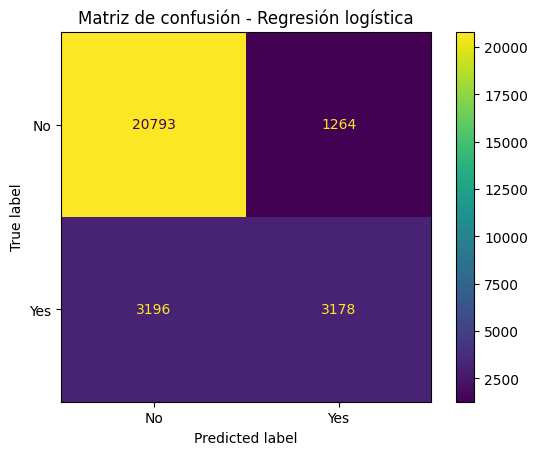

In [979]:
# graficamos la matriz de confusión para la regresión logística
cm_logistico = confusion_matrix(y_test, y_pred_logistico)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistico,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [980]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_logistico.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 20793
Falsos positivos: 1264
Falsos negativos: 3196
Verdaderos positivos: 3178


La matriz de confusión muestra que el modelo clasifica correctamente una gran cantidad de días sin lluvia, con 20862 verdaderos negativos. También detecta 3239 días lluviosos correctamente.

Sin embargo, se observan 3135 falsos negativos, es decir días en los que realmente llovió pero el modelo predijo que no llovería. Este valor es importante porque indica que el modelo todavía pierde una cantidad considerable de casos de lluvia.

También aparecen 1195 falsos positivos que corresponden a días en los que el modelo predijo lluvia pero finalmente no llovió. En este problema, los falsos positivos representan falsas alarmas, mientras que los falsos negativos representan lluvias no detectadas.

Esta matriz confirma lo que observamos en las métricas, el modelo tiene una buena accuracy general, pero el recall de la clase "Yes" es moderado, ya que no logra detectar todos los días lluviosos.

### Curva ROC y AUC

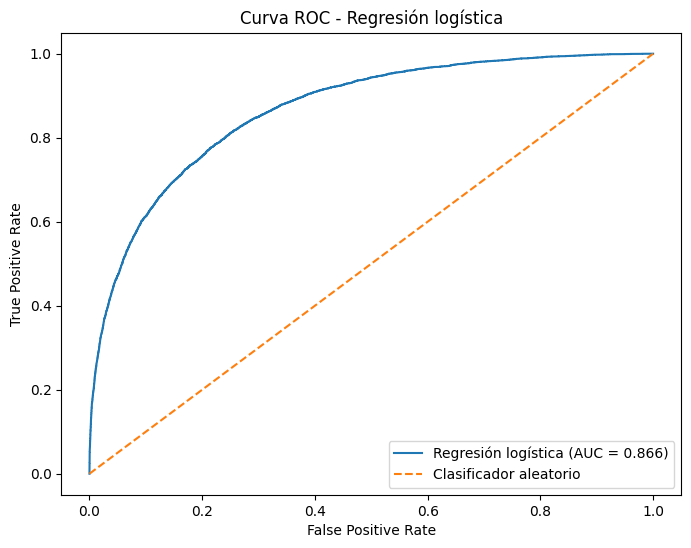

In [981]:
# Calculamos la curva ROC para la regresión logística.
fpr_logistico, tpr_logistico, thresholds_logistico = roc_curve(y_test,y_proba_logistico)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logistico,tpr_logistico,label=f"Regresión logística (AUC = {auc_logistico:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.show()

 El ROC-AUC fue de 0.870 lo cual indica que las probabilidades del modelo separan bastante bien los casos de lluvia y no lluvia, por eso el problema no necesariamente está en que el modelo no sirva, sino en que el umbral 0.5 puede no ser el más conveniente si queremos detectar más días de lluvia. Bajar el umbral podría aumentar el recall para detectar más lluvias reales pero la desventaja es que también podrían aumentar los falsos positivos

### Análisis del umbral de decisión

In [982]:
# buscamos un umbral posible maximizando la diferencia entre TPR y FPR
indice_mejor_umbral = np.argmax(tpr_logistico - fpr_logistico)
mejor_umbral = thresholds_logistico[indice_mejor_umbral]

print("Mejor umbral sugerido:", mejor_umbral)
print("TPR:", tpr_logistico[indice_mejor_umbral])
print("FPR:", fpr_logistico[indice_mejor_umbral])

Mejor umbral sugerido: 0.1871881161936222
TPR: 0.8107938500156887
FPR: 0.24939928367411707


In [983]:
# generamos nuevas predicciones usando el umbral sugerido
y_pred_logistico_umbral = (y_proba_logistico >= mejor_umbral).astype(int)

print(classification_report(y_test, y_pred_logistico_umbral))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83     22057
           1       0.48      0.81      0.61      6374

    accuracy                           0.76     28431
   macro avg       0.71      0.78      0.72     28431
weighted avg       0.83      0.76      0.78     28431



Con este nuevo umbral, el recall de la clase "Yes" aumenta de aproximadamente 0.51 a 0.80. Esto significa que el modelo detecta una mayor proporción de los días en los que realmente llueve. La precision de la clase "Yes" es 0.50 y la accuracy general disminuye a 0.78, esto pasa porque al bajar el umbral el modelo clasifica más casos como lluvia, lo que reduce los falsos negativos pero aumenta los falsos positivos.

Si se prioriza no perder lluvias reales conviene un umbral menor y si se prioriza evitar falsas alarmas conviene un umbral más alto.

## Ítem 3: implementación del modelo base

In [984]:
# implementamos modelo base con "DummyClassifier", predice siempre el que tiene mas frecuencia
modelo_base = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", DummyClassifier(strategy="most_frequent", random_state=42))
    ])

modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)

In [985]:
# calculamos métricas principales para evaluar el modelo base basado en frecuencia 
accuracy_base = accuracy_score(y_test, y_pred_base)
precision_base = precision_score(y_test, y_pred_base, zero_division=0)
recall_base = recall_score(y_test, y_pred_base, zero_division=0)
f1_base = f1_score(y_test, y_pred_base, zero_division=0)
auc_base = roc_auc_score(y_test, y_pred_base)

print("Accuracy:", accuracy_base)
print("Precision:", precision_base)
print("Recall:", recall_base)
print("F1-score:", f1_base)
print("ROC-AUC:", auc_base)

Accuracy: 0.7758080967957511
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.5


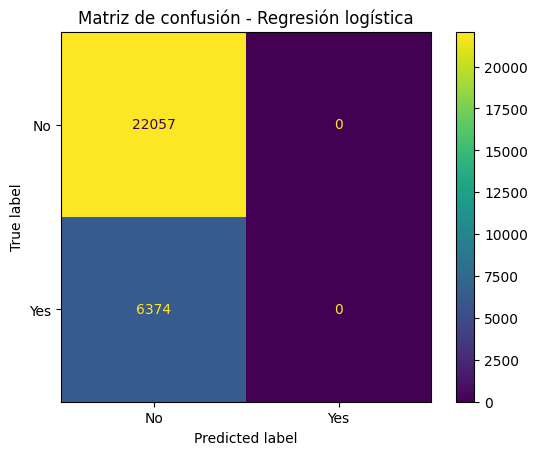

In [986]:
# graficamos la matriz de confusión para la regresión logística
cm_base = confusion_matrix(y_test, y_pred_base)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_base,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [987]:
# extraemos los valores de la matriz de confusión 
vn, fp, fn, vp = cm_base.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 22057
Falsos positivos: 0
Falsos negativos: 6374
Verdaderos positivos: 0


La matriz de confusión del modelo base muestra que el clasificador predice siempre la clase mayoritaria, es decir, No. Por eso clasifica correctamente los días sin lluvia, pero no detecta ningún caso de lluvia.
Esto confirma que la accuracy no alcanza para evaluar este problema, ya que un modelo puede obtener un valor aparentemente aceptable simplemente prediciendo siempre la clase más frecuente.

Modelo Base, si llovio hoy -Z llueve mañana

In [988]:

df_rain_train = X_train[["RainToday"]].copy()
df_rain_train["RainTomorrow"] = y_train.map({0: "No", 1: "Yes"})

# eliminamos filas donde RainToday sea nulo para observar la relación de forma directa
df_rain_train = df_rain_train.dropna(subset=["RainToday"])

tabla_rain_pct = pd.crosstab(
    df_rain_train["RainToday"],
    df_rain_train["RainTomorrow"],
    normalize="index"
) * 100

tabla_rain_pct = tabla_rain_pct.reindex(columns=["No", "Yes"])
tabla_rain_pct.round(2)

RainTomorrow,No,Yes
RainToday,,
No,84.84,15.16
Yes,53.43,46.57


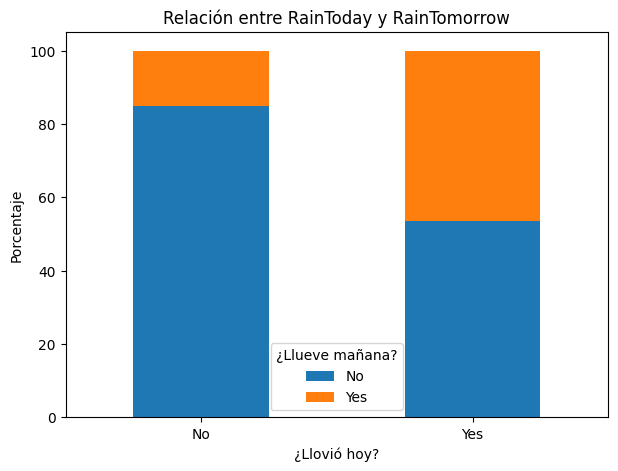

In [989]:
tabla_rain_pct.plot(kind="bar", stacked=True, figsize=(7, 5))

plt.title("Relación entre RainToday y RainTomorrow")
plt.xlabel("¿Llovió hoy?")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="¿Llueve mañana?")
plt.show()

En este caso vemos que cuando no llueve en el dia es muy probable que al dia siguiente tampoco llueva, pero para los dias que si llovió aunque se acerca un poco en su mayoria tampcoo llueve al dia siguiente deberia ser una mejor prediccion que simplemente predecir aue no llueve como en el anterior

In [990]:
# implementamos un modelo base basado en una regla simple:
# si RainToday = Yes, predecimos RainTomorrow = Yes; si RainToday = No, predecimos RainTomorrow = No

moda_raintoday_train = X_train["RainToday"].mode()[0]

y_pred_base_raintoday = (
    X_test["RainToday"]
    .fillna(moda_raintoday_train)
    .map({"No": 0, "Yes": 1})
    .astype(int)
)

In [991]:
# calculamos métricas principales para evaluar el modelo base basado en RainToday
accuracy_base_raintoday = accuracy_score(y_test, y_pred_base_raintoday)
precision_base_raintoday = precision_score(y_test, y_pred_base_raintoday, zero_division=0)
recall_base_raintoday = recall_score(y_test, y_pred_base_raintoday, zero_division=0)
f1_base_raintoday = f1_score(y_test, y_pred_base_raintoday, zero_division=0)
auc_base_raintoday = roc_auc_score(y_test, y_pred_base_raintoday)

print("Accuracy:", accuracy_base_raintoday)
print("Precision:", precision_base_raintoday)
print("Recall:", recall_base_raintoday)
print("F1-score:", f1_base_raintoday)
print("ROC-AUC:", auc_base_raintoday)

Accuracy: 0.7569554359677817
Precision: 0.4576619273301738
Recall: 0.45450266708503295
F1-score: 0.45607682619647355
ROC-AUC: 0.6494302336649266


El baseline basado en la variable raintoday tiene un poco menor Accuracy que la que predice "No" pero aumenta precision y recall ya que predice positivo para algunos casos.

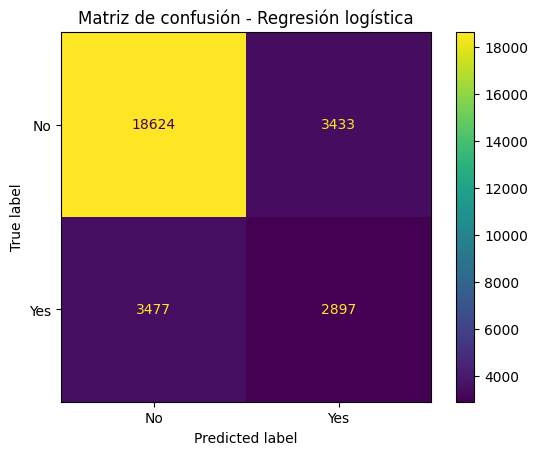

In [992]:
# graficamos la matriz de confusión para la regresión logística
cm_rain_today = confusion_matrix(y_test, y_pred_base_raintoday)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rain_today,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [993]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_rain_today.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 18624
Falsos positivos: 3433
Falsos negativos: 3477
Verdaderos positivos: 2897


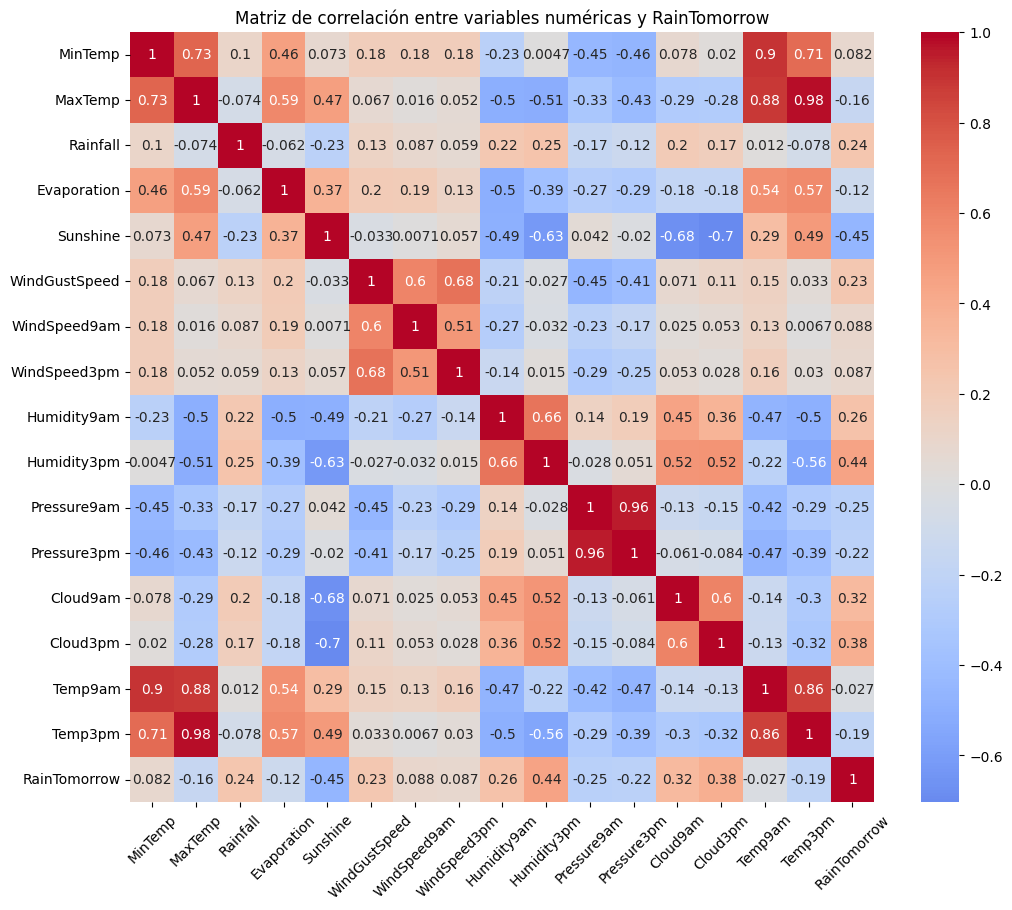

In [994]:
# copiamos las variables numéricas
df_corr = df_train[columnas_numericas].copy()

# agregamos el target codificado como variable binaria
df_corr["RainTomorrow"] = y_train

# calculamos la matriz de correlación incluyendo el target
correlacion2 = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion2, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas y RainTomorrow")
plt.xticks(rotation=45)
plt.show()

Elegimos usar la variable Sunshine para la regresion logistica de 1 variable

In [995]:
X_train_variable_unica = X_train[['Sunshine']]
X_test_unica = X_test[['Sunshine']]

# creamos un Pipeline que combina el preprocesamiento y la regresión logística
modelo_logistico_una_var = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_numerico),
    ("clasificador", LogisticRegression(max_iter=1000, random_state=42))
])

# entrenamos el modelo utilizando el conjunto de entrenamiento
modelo_logistico_una_var.fit(X_train_variable_unica, y_train)

# obtenemos las predicciones de clase sobre el conjunto de prueba
y_pred_una_var = modelo_logistico_una_var.predict(X_test_unica)

# obtenemos las probabilidades de pertenecer a la clase positiva
y_proba_logistico_una_var = modelo_logistico_una_var.predict_proba(X_test_unica)[:, 1]


In [996]:
# calculamos métricas principales para evaluar el modelo de regresión logística
accuracy_logistico = accuracy_score(y_test, y_pred_una_var)
precision_logistico = precision_score(y_test, y_pred_una_var)
recall_logistico = recall_score(y_test, y_pred_una_var)
f1_logistico = f1_score(y_test, y_pred_una_var)
auc_logistico = roc_auc_score(y_test, y_proba_logistico_una_var)

print("Accuracy:", accuracy_logistico)
print("Precision:", precision_logistico)
print("Recall:", recall_logistico)
print("F1-score:", f1_logistico)
print("ROC-AUC:", auc_logistico)

Accuracy: 0.7836164749744997
Precision: 0.5495535714285714
Recall: 0.1931283338562912
F1-score: 0.2858137915022057
ROC-AUC: 0.6950371003705932


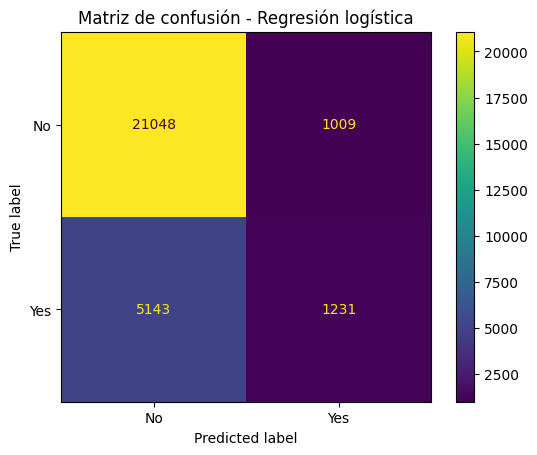

In [997]:
# graficamos la matriz de confusión para la regresión logística
cm_una_var = confusion_matrix(y_test, y_pred_una_var)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_una_var,display_labels=["No", "Yes"])

disp.plot()
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [998]:
# extraemos los valores de la matriz de confusión
vn, fp, fn, vp = cm_una_var.ravel()

print("Verdaderos negativos:", vn)
print("Falsos positivos:", fp)
print("Falsos negativos:", fn)
print("Verdaderos positivos:", vp)

Verdaderos negativos: 21048
Falsos positivos: 1009
Falsos negativos: 5143
Verdaderos positivos: 1231


La regresión logística con todas las variables supera a los modelos base porque, además de mantener una accuracy mayor, logra identificar una parte de los días con lluvia. Esto se observa especialmente en el recall y el F1-score de la clase positiva.

Por lo tanto, la regresión logística aporta valor respecto de una estrategia ingenua basada solamente en predecir siempre la clase mayoritaria, basada en el valor de una variable o la regresion logisticca de una osla variable.

## Item 4: Implementamos optimización de hiperparámetros

Optimizaremos:
* C porque controla la regularización, entonces probamos un rango amplio para  encontrar el equilibrio que mejor generalice y evitar overfitting
* class_weight, porque permite ajustar el peso de cada clase durante el entrenamiento e incluímos balanced para que el modelo no ignore la clase minoritaria (lluvia), por estar desbalanceado el dataset
  
  

In [999]:
# Grid search

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_params = {
    'clasificador__C': [0.01, 0.1, 1, 10, 100, 1000, 10000], # 7 valores
    'clasificador__class_weight': [None, 'balanced'] # 2 valores
}

# 7*2 = 14 combinaciones de hiperparámetros
# utilizamos 5 splits, entonces:
# nro. de entrenamientos = 5 * 14 = 70

modelo_grid = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])

grid_search = GridSearchCV(
    modelo_grid, grid_params, cv=cv, scoring='f1', n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_grid_model = grid_search.best_estimator_
grid_search_f1 = f1_score(y_test, best_grid_model.predict(X_test))
accuracy_grid = accuracy_score(y_test, best_grid_model.predict(X_test))
precision_grid = precision_score(y_test, best_grid_model.predict(X_test))
recall_grid = recall_score(y_test, best_grid_model.predict(X_test))

Utilizamos validación cruzada "k-folds" para obtener una estimación más robusta de F1-score, promediando los scores sobre distintas partes (folds) del dataset. Aplicamos StratifiedKFold para que las clases queden proporcionadas en cada fold, así evitamos cualquier sesgo en los datos 

Elegimos grid search por sobre las otras dos opciones porque el espacio de parámetros es muy pequeño (14 combinaciones) y en estos casos grid search es más eficiente y consume menos recursos para realizar la búsqueda que Optuna o Random Search

In [1000]:
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)
print("Accuracy:", accuracy_grid)
print("Precision:", precision_grid)
print("Recall:", recall_grid)
print("F1-score:", grid_search_f1)

Mejores parámetros: {'clasificador__C': 1, 'clasificador__class_weight': 'balanced'}
Mejor score: 0.6200810363055789
Accuracy: 0.7878372199359853
Precision: 0.5181490129484186
Recall: 0.7659240665202385
F1-score: 0.6181311724487212


Optimizando los hiperparámetros del modelo con grid search, logramos un F1-score de 0.62 en test, superando al dummy (F1 = 0) y al modelo base asumiendo que si llovió hoy, llueve mañana (F1 = 0.45)

La mejora respecto al modelo de regresión logística del item 2 (F1 = 0.59) es muy poca, lo que sugiere que ya alcanzamos el límite del modelo de regresión logística con este dataset

In [1001]:
best_grid_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [1002]:
preprocesamiento = best_grid_model.named_steps['preprocesamiento'] # ColumnTransformer
clasificador = best_grid_model.named_steps['clasificador'] # LogisticRegression

Desempaquetamos el pipeline, extrayendo preprocesador y clasificador

In [1003]:
X_train_scaled = preprocesamiento.transform(X_train)
X_test_scaled = preprocesamiento.transform(X_test)

Transformamos los datos para que Shap los reciba preprocesados como el clasificador del pipeline (pasan de df a array)

In [1004]:
OHE = preprocesamiento.named_transformers_["cat"].named_steps["encoder"]
columnas_categoricas_ohe = OHE.get_feature_names_out(columnas_categoricas)
feature_names = list(columnas_numericas) + list(columnas_categoricas_ohe)

Obtenemos el nombre de todas las columnas, numéricas + categóricas expandidas por OneHotEncoder

In [1005]:
# Crea un objeto explainer SHAP
explainer = shap.LinearExplainer(clasificador, X_train_scaled, feature_names=feature_names)

# Calcula los valores SHAP para un conjunto de ejemplos de prueba
shap_values = explainer.shap_values(X_test_scaled)

Background dataset has 113722 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=113722 when initializing the masker.
